---

# Quantum Circuits in Action: Defending Neural Networks from Adversarial Attacks

<span style="color: #008800">**Navid Azimi, Aditya Prakash, and Li Xiong**</span>


📁 Datasets: [MNIST](https://pytorch.org/vision/main/generated/torchvision.datasets.MNIST.html) | [CIFAR-10](https://pytorch.org/vision/main/generated/torchvision.datasets.CIFAR10.html) | [OrganAMNIST](https://medmnist.com/)


📌 Our project explores the adversarial robustness of classical Convolutional Neural Networks and Quanvolutional Neural Networks. Using the Torchattacks and ART libraries, adversarial attack methods will be applied to the models, while the PennyLane library will be used to design and train QNNs. The implementation involves training DNNs, CNNs, and QNNs on several datasets, followed by subjecting them to various adversarial attacks. Our goal is to compare the susceptibility of classical models and quanvolutional models to adversarial perturbations, with a focus on assessing whether quanvolutional neural networks offer increased robustness against adversarial attacks.

---


# 📚 Installing Libraries

In [1]:
# !pip install -r requirements.txt

In [2]:
!pip install torchattacks
!pip install --upgrade pip setuptools wheel
!pip install pennylane
!pip install adversarial-robustness-toolbox
!pip install tabulate
!pip install matplotlib
!pip install medmnist
!pip uninstall torch torchvision -y
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cu121

  Using cached pip-25.2-py3-none-any.whl.metadata (4.7 kB)
  Using cached setuptools-80.9.0-py3-none-any.whl.metadata (6.6 kB)
Using cached pip-25.2-py3-none-any.whl (1.8 MB)
Using cached setuptools-80.9.0-py3-none-any.whl (1.2 MB)


ERROR: To modify pip, please run the following command:
C:\Users\Home\anaconda3\envs\env2\python.exe -m pip install --upgrade pip setuptools wheel


Found existing installation: torch 2.5.1+cu121
Uninstalling torch-2.5.1+cu121:
  Successfully uninstalled torch-2.5.1+cu121
Found existing installation: torchvision 0.20.1+cu121
Uninstalling torchvision-0.20.1+cu121:
  Successfully uninstalled torchvision-0.20.1+cu121


You can safely remove it manually.
You can safely remove it manually.


Looking in indexes: https://download.pytorch.org/whl/cu121
  Using cached https://download.pytorch.org/whl/cu121/torch-2.5.1%2Bcu121-cp312-cp312-win_amd64.whl (2449.3 MB)
  Using cached https://download.pytorch.org/whl/cu121/torchvision-0.20.1%2Bcu121-cp312-cp312-win_amd64.whl (6.1 MB)

   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   ---------------------------------------- 0/2 [torch]
   -------------------------------------

---
# 📦 Importing Libraries

In [1]:
import os
import psutil
import shutil
import torch
import torchattacks
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
import torchvision.models as models
from torch.utils.data import DataLoader, Dataset, TensorDataset
import sys
import scipy
import time
import random
import pkg_resources
import importlib
import math
import gzip
import numpy as np
from torchvision.transforms import ToTensor
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import os
from PIL import Image
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt
from torch.utils.data import Subset
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score
import tqdm
import tabulate
from tabulate import tabulate
from art import config
from art.utils import load_dataset, get_file, compute_accuracy
from art.attacks.evasion import CarliniLInfMethod, FastGradientMethod, CarliniL2Method
from art.estimators.classification import PyTorchClassifier, KerasClassifier
from art.estimators.certification.randomized_smoothing import PyTorchRandomizedSmoothing
from medmnist import INFO, OrganAMNIST
import warnings
import importlib.util
import importlib.machinery
from qnn_toolkit import *
from noise_transforms import (
    AddGeometricNoise,
    AddGaussianNoise,
    AddSaltPepperNoise,
    AddOcclusionNoise,
    AddPoissonNoise
)

%matplotlib inline
warnings.filterwarnings("ignore")

C:\Users\Home\AppData\Local\Temp\ipykernel_20440\3644880122.py:16: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources
c:\Users\Home\anaconda3\envs\env2\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
"""
spec = importlib.util.spec_from_loader(
    "qnn_toolkit",
    importlib.machinery.SourcelessFileLoader("qnn_toolkit", "qnn_toolkit.cpython-312.pyc")
)
qnn_toolkit = importlib.util.module_from_spec(spec)
sys.modules["qnn_toolkit"] = qnn_toolkit
spec.loader.exec_module(qnn_toolkit)
"""

'\nspec = importlib.util.spec_from_loader(\n    "qnn_toolkit",\n    importlib.machinery.SourcelessFileLoader("qnn_toolkit", "qnn_toolkit.cpython-312.pyc")\n)\nqnn_toolkit = importlib.util.module_from_spec(spec)\nsys.modules["qnn_toolkit"] = qnn_toolkit\nspec.loader.exec_module(qnn_toolkit)\n'

---
# 🖥️ System Information

In [3]:
# RAM information
print(f"RAM Info:")
ram = psutil.virtual_memory()
print(f"Total RAM: {ram.total / (1024 ** 3):.2f} GB")
print(f"Available RAM: {ram.available / (1024 ** 3):.2f} GB\n")

# Disk information
print(f"Disk Info:")
total, used, free = shutil.disk_usage("/")
print(f"Total Disk Space: {total // (2**30)} GB")
print(f"Free Disk Space: {free // (2**30)} GB\n")

# CPU Information
print(f"CPU Info:")
cpu_cores = psutil.cpu_count(logical=False)
cpu_threads = psutil.cpu_count(logical=True)
print(f"Number of Physical Cores: {cpu_cores}")
print(f"Number of Logical Cores: {cpu_threads}")
cpu_info = os.popen("lscpu").read()
print(cpu_info)

# GPU information
print(f"GPU Info:")
print("Available GPUs:", torch.cuda.device_count())
for i in range(torch.cuda.device_count()):
    print(f" - GPU {i}: {torch.cuda.get_device_name(i)}")
    print(f" - GPU Memory Total: {torch.cuda.get_device_properties(i).total_memory / 1024**3:.2f} GB")
print("PyTorch version:", torch.__version__)
print("CUDA version:", torch.version.cuda)

RAM Info:
Total RAM: 15.64 GB
Available RAM: 3.67 GB

Disk Info:
Total Disk Space: 456 GB
Free Disk Space: 192 GB

CPU Info:
Number of Physical Cores: 12
Number of Logical Cores: 16

GPU Info:
Available GPUs: 1
 - GPU 0: NVIDIA GeForce MX570 A
 - GPU Memory Total: 2.00 GB
PyTorch version: 2.5.1+cu121
CUDA version: 12.1



---
# 📌 Options & Parameters - Part One

In [4]:
# Set "CUDA_VISIBLE_DEVICES" to "0" to tell CUDA to only use the first GPU
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [5]:
global device
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(device)

cuda


In [6]:
# Select the Ansatz archuitecture from the following: no_entanglement_ansatz, linear_entanglement_ansatz, full_entanglement_ansatz, star_entanglement_ansatz
global entanglement_type
entanglement_type = 'no_entanglement_ansatz'

In [7]:
# Select the dataset from the following: MNIST, CIFAR10, OrganAMNIST
global dataset_name
dataset_name = 'OrganAMNIST'

In [8]:
# Select the Base Neural Network from the following: CNN-MNIST, DNN-MNIST, CNN-CIFAR10, DNN-CIFAR10, CNN-OrganAMNIST, DNN-OrganAMNIST
global NN_name
NN_name = 'DNN-OrganAMNIST'

In [9]:
# Select the noise type from the following: none, gaussian, salt_pepper, occlusion, poisson, geometric
global noise_type
noise_type = "none"

In [10]:
global num_epochs
num_epochs = 10

In [11]:
# Number of classes: 10 for MNIST and CIFAR10 datasets, 11 for OrganAMNIST dataset
global NUM_CLASSES
NUM_CLASSES = 11

In [12]:
# Enable the creation of the QNN model
global construct_qnn_model
construct_qnn_model = False;

In [13]:
# QNN settings
qnn_settings = {
    "output_dim": NUM_CLASSES,                              # output_dim: Output dimension (number of classes)
    "circuit_depth": 1,                                     # circuit_depth: Depth of the quantum circuit
    "noise_strength": 0.005,                                # Initial strength of quantum noise (0.0 to 1.0)
    "input_noise_injection": False,                          # Enable random perturbations to input data
    "entanglement_type": 'no_entanglement_ansatz',      # Type of entanglement to use in the quantum circuit
    "use_dynamic_weights": True,                            # Whether to use dynamic weighting between classical and quantum outputs
    "encoding_method": 'enhanced_angle',                    # Method for encoding classical features into quantum states  ('angle', 'enhanced_angle')
    "noise_model": 'mixed'                                  # Type of noise model to use in quantum simulation ('depolarizing', 'amplitude_damping', 'phase_damping'. 'mixed')
}


---
# 🕸️ The CNN and DNN Models

In [14]:
if NN_name == 'CNN-MNIST':

    class CNN(nn.Module):
        def __init__(self, num_classes=10):
            super().__init__()
            weights = models.ResNet18_Weights.DEFAULT
            self.resnet18 = models.resnet18(weights=weights)
            # Adapt the first conv layer to accept 1 channel
            old_conv = self.resnet18.conv1
            self.resnet18.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
            # Initialize new conv1 weights as mean of old weights across RGB channels
            with torch.no_grad():
                self.resnet18.conv1.weight[:] = old_conv.weight.mean(dim=1, keepdim=True)
            # Adapt output layer
            self.resnet18.fc = nn.Linear(self.resnet18.fc.in_features, num_classes)
            self.logsoftmax = nn.LogSoftmax(dim=1)

        def forward(self, x):
            x = self.resnet18(x)
            return self.logsoftmax(x)

elif NN_name == 'DNN-MNIST':

    class DNN(nn.Module):
        def __init__(self):
            super(DNN, self).__init__()

            # Each MNIST image is 28x28, so the input size is 784
            self.fc1 = nn.Linear(28*28, 512)
            self.bn1 = nn.BatchNorm1d(512)
            self.drop1 = nn.Dropout(0.2)

            self.fc2 = nn.Linear(512, 256)
            self.bn2 = nn.BatchNorm1d(256)
            self.drop2 = nn.Dropout(0.2)

            self.fc3 = nn.Linear(256, 128)
            self.bn3 = nn.BatchNorm1d(128)
            self.drop3 = nn.Dropout(0.2)

            # Output layer for 10 classes
            self.fc4 = nn.Linear(128, 10)

        def forward(self, x):
            # Flatten 28x28 images to 784-dimensional vectors
            x = x.view(x.size(0), -1)

            # 1st layer: FC -> BN -> ReLU -> Dropout
            x = F.relu(self.bn1(self.fc1(x)))
            x = self.drop1(x)

            # 2nd layer
            x = F.relu(self.bn2(self.fc2(x)))
            x = self.drop2(x)

            # 3rd layer
            x = F.relu(self.bn3(self.fc3(x)))
            x = self.drop3(x)

            # Output layer (log_softmax for classification)
            x = self.fc4(x)
            return F.log_softmax(x, dim=1)

elif NN_name == 'CNN-CIFAR10':

    class CNN(nn.Module):
        def __init__(self, num_classes=10):
            super().__init__()
            weights = models.ResNet18_Weights.DEFAULT
            self.resnet18 = models.resnet18(weights=weights)
            # Change the final fully connected layer for CIFAR-10 (10 classes)
            self.resnet18.fc = nn.Linear(self.resnet18.fc.in_features, num_classes)
            self.logsoftmax = nn.LogSoftmax(dim=1)

        def forward(self, x):
            x = self.resnet18(x)
            return self.logsoftmax(x)

elif NN_name == 'DNN-CIFAR10':

    class DNN(nn.Module):
        def __init__(self):
            super(DNN, self).__init__()

            # Each CIFAR-10 image is 3 x 32 x 32, so the input size is 3072
            self.fc1 = nn.Linear(32*32*3, 1024)
            self.bn1 = nn.BatchNorm1d(1024)
            self.drop1 = nn.Dropout(0.2)

            self.fc2 = nn.Linear(1024, 512)
            self.bn2 = nn.BatchNorm1d(512)
            self.drop2 = nn.Dropout(0.2)

            self.fc3 = nn.Linear(512, 256)
            self.bn3 = nn.BatchNorm1d(256)
            self.drop3 = nn.Dropout(0.2)

            self.fc4 = nn.Linear(256, 128)
            self.bn4 = nn.BatchNorm1d(128)
            self.drop4 = nn.Dropout(0.2)

            # Output layer for 10 classes in CIFAR-10
            self.fc5 = nn.Linear(128, 10)

        def forward(self, x):
            # Flatten the 3D input to a 1D vector
            x = x.view(x.size(0), -1)

            # First layer
            x = F.relu(self.bn1(self.fc1(x)))
            x = self.drop1(x)

            # Second layer
            x = F.relu(self.bn2(self.fc2(x)))
            x = self.drop2(x)

            # Third layer
            x = F.relu(self.bn3(self.fc3(x)))
            x = self.drop3(x)

            # Fourth layer
            x = F.relu(self.bn4(self.fc4(x)))
            x = self.drop4(x)

            # Output layer
            x = self.fc5(x)
            return F.log_softmax(x, dim=1)

elif NN_name == 'CNN-OrganAMNIST':

    class CNN(nn.Module):
        def __init__(self, num_classes=11):
            super().__init__()
            weights = models.ResNet18_Weights.DEFAULT
            self.resnet18 = models.resnet18(weights=weights)
            # Adapt the first conv layer for 1-channel (grayscale) OrganAMNIST images
            old_conv = self.resnet18.conv1
            self.resnet18.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
            with torch.no_grad():
                self.resnet18.conv1.weight[:] = old_conv.weight.mean(dim=1, keepdim=True)
            self.resnet18.fc = nn.Linear(self.resnet18.fc.in_features, num_classes)
            self.logsoftmax = nn.LogSoftmax(dim=1)

        def forward(self, x):
            x = self.resnet18(x)
            return self.logsoftmax(x)

elif NN_name == 'DNN-OrganAMNIST':

    class DNN(nn.Module):
        def __init__(self):
            super(DNN, self).__init__()

            # Each OrganAMNIST image is 28x28, so the input size is 784
            self.fc1 = nn.Linear(28*28, 512)
            self.bn1 = nn.BatchNorm1d(512)
            self.drop1 = nn.Dropout(0.2)

            self.fc2 = nn.Linear(512, 256)
            self.bn2 = nn.BatchNorm1d(256)
            self.drop2 = nn.Dropout(0.2)

            self.fc3 = nn.Linear(256, 128)
            self.bn3 = nn.BatchNorm1d(128)
            self.drop3 = nn.Dropout(0.2)

            # Output layer for 11 classes in OrganAMNIST
            self.fc4 = nn.Linear(128, 11)

        def forward(self, x):
            # Flatten 28x28 images to 784-dimensional vectors
            x = x.view(x.size(0), -1)

            # 1st layer: FC -> BN -> ReLU -> Dropout
            x = F.relu(self.bn1(self.fc1(x)))
            x = self.drop1(x)

            # 2nd layer
            x = F.relu(self.bn2(self.fc2(x)))
            x = self.drop2(x)

            # 3rd layer
            x = F.relu(self.bn3(self.fc3(x)))
            x = self.drop3(x)

            # Output layer (log_softmax for classification)
            x = self.fc4(x)
            return F.log_softmax(x, dim=1)

else:
    print(f"Unsupported NN_name: {NN_name}")

In [15]:
if NN_name == 'DNN-MNIST' or NN_name == 'DNN-CIFAR10' or NN_name == 'DNN-OrganAMNIST':
    dnn_model = DNN().to(device)

    print("DNN Model's Architecture:")
    print(dnn_model)

elif NN_name == 'CNN-MNIST' or NN_name == 'CNN-CIFAR10' or NN_name == 'CNN-OrganAMNIST':
    cnn_model = CNN().to(device)

    print("CNN Model's Architecture:")
    print(cnn_model)

else:
    print(f"Unsupported NN_name: {NN_name}")

DNN Model's Architecture:
DNN(
  (fc1): Linear(in_features=784, out_features=512, bias=True)
  (bn1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (drop1): Dropout(p=0.2, inplace=False)
  (fc2): Linear(in_features=512, out_features=256, bias=True)
  (bn2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (drop2): Dropout(p=0.2, inplace=False)
  (fc3): Linear(in_features=256, out_features=128, bias=True)
  (bn3): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (drop3): Dropout(p=0.2, inplace=False)
  (fc4): Linear(in_features=128, out_features=11, bias=True)
)



---
# ⚛️ The QNN Model

In [16]:
def get_qnn_model(cnn_model: nn.Module, device: torch.device, **kwargs) -> QNN:
    """
    Create a QNN model with specified settings

    Args:
        cnn_model: Classical CNN model
        device: Computation device
        **kwargs: Additional arguments to override defaults

    Returns:
        Configured QNN model
    """
    settings = {**qnn_settings, **kwargs}

    return QNN(
        cnn_model=cnn_model,
        device=device,
        **settings
    )

In [17]:
# Create an instance of the qnn model
if construct_qnn_model:
    if NN_name == 'CNN-MNIST' or NN_name == 'CNN-CIFAR10' or NN_name == 'CNN-OrganAMNIST':
        # Call the get_qnn_model function to get the QNN model with the settings
        qnn_model = get_qnn_model(cnn_model=cnn_model, device=device).to(device)

        # Print the qnn model architecture
        print("Hybrid QNN Model's Architecture:")
        print(qnn_model)

In [18]:
if construct_qnn_model:
    metadata = qnn_model.get_metadata()
    print(metadata)


---
# 📌 Options & Parameters - Part Two


In [19]:
# Select the target model from the following: dnn_model, cnn_model, qnn_model
global target_model
target_model = dnn_model

In [20]:
optimizer = optim.Adam(target_model.parameters())

In [21]:
loss_fn = nn.NLLLoss()

---
# 🧫 (Optional) Noise-Augmented Training


In [22]:
def get_transform(noise_type="none"):
    if noise_type == "gaussian":
        transform_with_noise = transforms.Compose([
            transforms.ToTensor(),
            AddGaussianNoise(mean=0.01, std=0.01) # Apply Gaussian noise with mean 0.1 and std 0.1
        ])
    elif noise_type == "salt_pepper":
        transform_with_noise = transforms.Compose([
            transforms.ToTensor(),
            AddSaltPepperNoise(prob=0.05) # Apply salt and pepper noise with probability 5%
        ])
    elif noise_type == "occlusion":
        transform_with_noise = transforms.Compose([
            transforms.ToTensor(),
            AddOcclusionNoise(occlusion_size=4) # Apply occlusion noise with a square box of size 4x4
        ])
    elif noise_type == "poisson":
        transform_with_noise = transforms.Compose([
            transforms.ToTensor(),
            AddPoissonNoise(scale=3)  # Apply Poisson noise with a scaling factor of 3
        ])
    elif noise_type == "geometric":
        transform_with_noise = transforms.Compose([
            transforms.ToTensor(),
            AddGeometricNoise(dataset_name)  # Apply geometric noise
        ])
    else:
        transform_with_noise = transforms.Compose([
            transforms.ToTensor() # Convert PIL image to tensor
        ])

    return transform_with_noise

In [23]:
selected_transform = get_transform(noise_type)

---
# 🛢️ Dataset


In [24]:
if dataset_name == 'MNIST':
    data_dir = './data/MNIST/'
    print(data_dir)
    train_set = datasets.MNIST(data_dir, train=True, download=True, transform=selected_transform)
    test_set = datasets.MNIST(data_dir, train=False, download=True, transform=selected_transform)

elif dataset_name == 'CIFAR10':
    data_dir = './data/CIFAR10/'
    print(data_dir)
    train_set = datasets.CIFAR10(data_dir, train=True, download=True, transform=selected_transform)
    test_set = datasets.CIFAR10(data_dir, train=False, download=True, transform=selected_transform)

elif dataset_name == 'OrganAMNIST':
    data_dir = './data/OrganAMNIST/'
    os.makedirs(data_dir, exist_ok=True)
    print(data_dir)
    train_set = OrganAMNIST(root=data_dir, split='train', download=True, transform=selected_transform)
    test_set = OrganAMNIST(root=data_dir, split='test', download=True, transform=selected_transform)

else:
    raise ValueError("Invalid dataset name.")

./data/OrganAMNIST/
Using downloaded and verified file: ./data/OrganAMNIST/organamnist.npz
Using downloaded and verified file: ./data/OrganAMNIST/organamnist.npz


In [25]:
if dataset_name == 'MNIST':
    def filtered_dataset(train_set, test_set, filtered=0, dataset_name=None):
        if filtered == 0:  # Classes 0 and 1 only
            if(True):
                try:
                    train_indexes_0 = torch.where(train_set.targets == 0)[0]
                    train_indexes_1 = torch.where(train_set.targets == 1)[0]
                    test_indexes_0 = torch.where(test_set.targets == 0)[0]
                    test_indexes_1 = torch.where(test_set.targets == 1)[0]
                except AttributeError:
                    train_indexes_0 = torch.where(torch.tensor(train_set.labels) == 0)[0]
                    train_indexes_1 = torch.where(torch.tensor(train_set.labels) == 1)[0]
                    test_indexes_0 = torch.where(torch.tensor(test_set.labels) == 0)[0]
                    test_indexes_1 = torch.where(torch.tensor(test_set.labels) == 1)[0]

            num_to_sample_train = min(len(train_indexes_0), len(train_indexes_1))
            num_to_sample_test = min(len(test_indexes_0), len(test_indexes_1))

            sampled_train_indexes_0 = train_indexes_0[torch.randperm(len(train_indexes_0))[:num_to_sample_train]]
            sampled_train_indexes_1 = train_indexes_1[torch.randperm(len(train_indexes_1))[:num_to_sample_train]]
            sampled_test_indexes_0 = test_indexes_0[torch.randperm(len(test_indexes_0))[:num_to_sample_test]]
            sampled_test_indexes_1 = test_indexes_1[torch.randperm(len(test_indexes_1))[:num_to_sample_test]]

            selected_train_indexes = torch.cat([sampled_train_indexes_0, sampled_train_indexes_1])
            selected_test_indexes = torch.cat([sampled_test_indexes_0, sampled_test_indexes_1])

        elif filtered == 1:  # All 10 classes
            train_indexes = []
            test_indexes = []
            for i in range(10):
                if(True):
                    try:
                        train_idx = torch.where(train_set.targets == i)[0]
                        test_idx = torch.where(test_set.targets == i)[0]
                    except AttributeError:
                        train_idx = torch.where(torch.tensor(train_set.labels) == i)[0]
                        test_idx = torch.where(torch.tensor(test_set.labels) == i)[0]

                train_indexes.append(train_idx)
                test_indexes.append(test_idx)

            min_num_samples_train = min(len(idx) for idx in train_indexes)
            min_num_samples_test = min(len(idx) for idx in test_indexes)

            sampled_train_indexes = []
            sampled_test_indexes = []
            for train_idx, test_idx in zip(train_indexes, test_indexes):
                sampled_train_indexes.append(train_idx[torch.randperm(len(train_idx))[:min_num_samples_train]])
                sampled_test_indexes.append(test_idx[torch.randperm(len(test_idx))[:min_num_samples_test]])

            selected_train_indexes = torch.cat(sampled_train_indexes)
            selected_test_indexes = torch.cat(sampled_test_indexes)

        else:
            raise ValueError("Invalid value for 'filtered'. Choose either 0 or 1.")

        filtered_train_set = torch.utils.data.Subset(train_set, selected_train_indexes)
        filtered_test_set = torch.utils.data.Subset(test_set, selected_test_indexes)

        return filtered_train_set, filtered_test_set

elif dataset_name == 'CIFAR10':
    def filtered_dataset(train_set, test_set, filtered=0, dataset_name=None):
        # CIFAR-10 classes:
        # 0: airplane, 1: automobile, 2: bird, 3: cat, 4: deer, 5: dog, 6: frog, 7: horse, 8: ship, 9: truck

        # Convert targets to tensors if they are lists
        train_targets_tensor = torch.tensor(train_set.targets)
        test_targets_tensor = torch.tensor(test_set.targets)

        if filtered == 0:  # Classes 0 and 1 only
            train_indexes_0 = torch.where(train_targets_tensor == 0)[0]
            train_indexes_1 = torch.where(train_targets_tensor == 1)[0]
            test_indexes_0 = torch.where(test_targets_tensor == 0)[0]
            test_indexes_1 = torch.where(test_targets_tensor == 1)[0]

            num_to_sample_train = min(len(train_indexes_0), len(train_indexes_1))
            num_to_sample_test = min(len(test_indexes_0), len(test_indexes_1))

            sampled_train_indexes_0 = train_indexes_0[torch.randperm(len(train_indexes_0))[:num_to_sample_train]]
            sampled_train_indexes_1 = train_indexes_1[torch.randperm(len(train_indexes_1))[:num_to_sample_train]]
            sampled_test_indexes_0 = test_indexes_0[torch.randperm(len(test_indexes_0))[:num_to_sample_test]]
            sampled_test_indexes_1 = test_indexes_1[torch.randperm(len(test_indexes_1))[:num_to_sample_test]]

            selected_train_indexes = torch.cat([sampled_train_indexes_0, sampled_train_indexes_1])
            selected_test_indexes = torch.cat([sampled_test_indexes_0, sampled_test_indexes_1])

        elif filtered == 1:  # All 10 classes
            train_indexes = []
            test_indexes = []
            for i in range(10):
                train_idx = torch.where(train_targets_tensor == i)[0]
                test_idx = torch.where(test_targets_tensor == i)[0]

                train_indexes.append(train_idx)
                test_indexes.append(test_idx)

            min_num_samples_train = min(len(idx) for idx in train_indexes)
            min_num_samples_test = min(len(idx) for idx in test_indexes)

            sampled_train_indexes = []
            sampled_test_indexes = []
            for train_idx, test_idx in zip(train_indexes, test_indexes):
                sampled_train_indexes.append(train_idx[torch.randperm(len(train_idx))[:min_num_samples_train]])
                sampled_test_indexes.append(test_idx[torch.randperm(len(test_idx))[:min_num_samples_test]])

            selected_train_indexes = torch.cat(sampled_train_indexes)
            selected_test_indexes = torch.cat(sampled_test_indexes)

        else:
            raise ValueError("Invalid value for 'filtered'. Choose either 0 or 1.")

        filtered_train_set = torch.utils.data.Subset(train_set, selected_train_indexes)
        filtered_test_set = torch.utils.data.Subset(test_set, selected_test_indexes)

        return filtered_train_set, filtered_test_set

elif dataset_name == 'OrganAMNIST':
    def filtered_dataset(train_set, test_set, filtered=0, dataset_name=None):
        # OrganAMNIST classes:
        # 0: bladder, 1: femur-left, 2: femur-right, 3: heart, 4: kidney-left, 5: kidney-right, 6: liver, 7: lung-left, 8: lung-right, 9: pancreas, 10: spleen

        train_targets_tensor = torch.tensor(train_set.labels)
        test_targets_tensor = torch.tensor(test_set.labels)

        if filtered == 0:  # Classes 0 and 1 only
            train_indexes_0 = torch.where(train_targets_tensor == 0)[0]
            train_indexes_1 = torch.where(train_targets_tensor == 1)[0]
            test_indexes_0 = torch.where(test_targets_tensor == 0)[0]
            test_indexes_1 = torch.where(test_targets_tensor == 1)[0]

            num_to_sample_train = min(len(train_indexes_0), len(train_indexes_1))
            num_to_sample_test = min(len(test_indexes_0), len(test_indexes_1))

            sampled_train_indexes_0 = train_indexes_0[torch.randperm(len(train_indexes_0))[:num_to_sample_train]]
            sampled_train_indexes_1 = train_indexes_1[torch.randperm(len(train_indexes_1))[:num_to_sample_train]]
            sampled_test_indexes_0 = test_indexes_0[torch.randperm(len(test_indexes_0))[:num_to_sample_test]]
            sampled_test_indexes_1 = test_indexes_1[torch.randperm(len(test_indexes_1))[:num_to_sample_test]]

            selected_train_indexes = torch.cat([sampled_train_indexes_0, sampled_train_indexes_1])
            selected_test_indexes = torch.cat([sampled_test_indexes_0, sampled_test_indexes_1])

        elif filtered == 1:  # All 11 classes
            train_indexes = []
            test_indexes = []
            for i in range(11):
                train_idx = torch.where(train_targets_tensor == i)[0]
                test_idx = torch.where(test_targets_tensor == i)[0]
                train_indexes.append(train_idx)
                test_indexes.append(test_idx)

            min_num_samples_train = min(len(idx) for idx in train_indexes)
            min_num_samples_test = min(len(idx) for idx in test_indexes)

            sampled_train_indexes = []
            sampled_test_indexes = []
            for train_idx, test_idx in zip(train_indexes, test_indexes):
                sampled_train_indexes.append(train_idx[torch.randperm(len(train_idx))[:min_num_samples_train]])
                sampled_test_indexes.append(test_idx[torch.randperm(len(test_idx))[:min_num_samples_test]])

            selected_train_indexes = torch.cat(sampled_train_indexes)
            selected_test_indexes = torch.cat(sampled_test_indexes)
        else:
            raise ValueError("Invalid value for 'filtered'. Choose either 0 or 1.")

        filtered_train_set = torch.utils.data.Subset(train_set, selected_train_indexes)
        filtered_test_set = torch.utils.data.Subset(test_set, selected_test_indexes)
        return filtered_train_set, filtered_test_set

else:
    raise ValueError("Invalid dataset name.")

In [26]:
global filtered_train_set, filtered_test_set
global filtered_train_loader, filtered_test_loader

print("Dataset:", dataset_name)

filtered_train_set, filtered_test_set = filtered_dataset(train_set, test_set, filtered=1)

# Select 100% of samples
def subset_dataset(dataset, fraction=1, seed=42):
    np.random.seed(seed)
    indices = np.random.choice(len(dataset), int(len(dataset) * fraction), replace=False)
    return Subset(dataset, indices)

filtered_train_set = subset_dataset(filtered_train_set, fraction=1)
filtered_test_set = subset_dataset(filtered_test_set, fraction=1)

filtered_train_loader = DataLoader(filtered_train_set, batch_size=128, shuffle=True)
filtered_test_loader = DataLoader(filtered_test_set, batch_size=128)

# Print the exact number of images in the filtered sets
print("Number of images in the filtered training set:", len(filtered_train_set))
print("Number of images in the filtered test set:", len(filtered_test_set))

# Print the number of batches in the data loaders
print("Number of batches in the filtered training set:", len(filtered_train_loader))
print("Number of batches in the filtered test set:", len(filtered_test_loader))

Dataset: OrganAMNIST
Number of images in the filtered training set: 14927
Number of images in the filtered test set: 8624
Number of batches in the filtered training set: 117
Number of batches in the filtered test set: 68



---
# 🧪 Model Evaluation

In [27]:
def load_clean_model(model, save_dir):
    # Model folder
    # model_path = f"{save_dir}/clean_model.pt"
    # model_path = f"{save_dir}/clean_model.pth"

    target_model_name = target_model.__class__.__name__.lower() + "_model"

    if target_model_name == 'qnn_model':
        filename = f"clean_model-{str(dataset_name)}-{str(target_model_name)}-{str(entanglement_type)}.pt"
    else:
        filename = f"clean_model-{str(dataset_name)}-{str(target_model_name)}.pt"

    model_path = os.path.join(save_dir, filename)

    if not os.path.exists(model_path):
        raise FileNotFoundError(f"Model file not found in {model_path}")

    # model = torch.load(model_path, weights_only=False)
    # model.load_state_dict(torch.load(model_path))

    model = torch.load(model_path, weights_only=False)  # weights_only param is rarely used, but kept as you had
    model.eval()

    print(f"Loaded model from {model_path}")
    return model

In [28]:
def evaluate(model, data_loader, loss_fn, device):
    global ODR
    test_loss = 0.0
    test_accuracy = 0.0
    num_misclassified = 0

    # Lists to store predictions and true labels for metric calculations
    all_labels = []
    all_predictions = []

    # Switch model to evaluation mode
    model.eval()

    misclassified_images = []
    misclassified_labels = []
    correctly_classified_images = []
    correctly_classified_labels = []
    misclassified_preds = []

    # Determine the total size of the dataset in the data_loader
    dataset_size = len(data_loader.dataset)
    print(f"Number of clean test images: {dataset_size}")

    # Disable gradient calculation for evaluation
    with torch.no_grad():
        total_batches = 0
        for x, y in data_loader:
            # Move inputs/labels to the desired device
            x, y = x.to(device), y.to(device)
            y = y.squeeze()

            # Forward pass
            logits = model(x)

            # Calculate batch loss
            batch_loss = loss_fn(logits, y)
            test_loss += batch_loss.item()

            # Get predictions and calculate batch accuracy
            preds = torch.argmax(logits, dim=1)
            test_accuracy += torch.sum(preds == y).item()

            # Append predictions and labels to the lists
            all_predictions.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

            correct_inds = torch.where(preds == y)[0]
            if len(correct_inds) > 0:
                correctly_classified_images.append(x[correct_inds].cpu())
                correctly_classified_labels.append(y[correct_inds].cpu())

            # Track misclassified samples
            incorrect_inds = torch.where(preds != y)[0]
            num_misclassified += len(incorrect_inds)
            if len(incorrect_inds) > 0:
                # Move misclassified items to CPU
                misclassified_images.append(x[incorrect_inds].cpu())
                misclassified_labels.append(y[incorrect_inds].cpu())
                misclassified_preds.append(preds[incorrect_inds].cpu())

            total_batches += 1

    # Concatenate all correctly classified examples
    correct_images = torch.cat(correctly_classified_images)
    correct_labels = torch.cat(correctly_classified_labels)

    # Average loss over all batches
    test_loss /= total_batches
    # Accuracy over the entire dataset
    test_accuracy = test_accuracy / dataset_size

    ODR = test_accuracy

    # Print the summary
    print(f"Number of misclassified images: {num_misclassified} out of {dataset_size}")
    print(f"Test loss: {test_loss:.4f} | Test Accuracy: {test_accuracy:.4f}")
    print(f"ODR: {ODR:.2%}\n")

    # Calculate and print additional metrics
    micro_precision = precision_score(all_labels, all_predictions, average='micro', zero_division=0)
    micro_recall = recall_score(all_labels, all_predictions, average='micro', zero_division=0)
    micro_f1 = f1_score(all_labels, all_predictions, average='micro', zero_division=0)

    macro_precision = precision_score(all_labels, all_predictions, average='macro', zero_division=0)
    macro_recall = recall_score(all_labels, all_predictions, average='macro', zero_division=0)
    macro_f1 = f1_score(all_labels, all_predictions, average='macro', zero_division=0)

    weighted_precision = precision_score(all_labels, all_predictions, average='weighted', zero_division=0)
    weighted_recall = recall_score(all_labels, all_predictions, average='weighted', zero_division=0)
    weighted_f1 = f1_score(all_labels, all_predictions, average='weighted', zero_division=0)

    table_data = [
        ["Micro-average", f"{micro_precision:.4f}", f"{micro_recall:.4f}", f"{micro_f1:.4f}"],
        ["Macro-average", f"{macro_precision:.4f}", f"{macro_recall:.4f}", f"{macro_f1:.4f}"],
        ["Weighted-average", f"{weighted_precision:.4f}", f"{weighted_recall:.4f}", f"{weighted_f1:.4f}"]
    ]

    headers = ["Metric", "Precision", "Recall", "F1-Score"]
    print(tabulate(table_data, headers=headers, tablefmt="grid"))

    # Handle edge cases if nothing is misclassified
    if len(misclassified_images) == 0:
        misclassified_images.append(torch.tensor([]))
    if len(misclassified_labels) == 0:
        misclassified_labels.append(torch.tensor([]))
    if len(misclassified_preds) == 0:
        misclassified_preds.append(torch.tensor([]))

    return (
        test_loss,
        test_accuracy,
        [torch.cat(misclassified_images)],
        [torch.cat(misclassified_labels)],
        [torch.cat(misclassified_preds)],
        correct_images,
        correct_labels
    )

In [29]:
# Model folder
save_dir = 'clean_models'
# Loading
clean_model = load_clean_model(target_model, save_dir)

Loaded model from clean_models\clean_model-OrganAMNIST-dnn_model.pt


In [30]:
# Start the timer
start_time = time.time()
# Evaluation
test_loss, test_acc, misclassified_images, misclassified_labels, misclassified_preds, correct_images, correct_labels = evaluate(
    clean_model, filtered_test_loader, loss_fn, device
)
# End the timer
end_time = time.time()

Number of clean test images: 8624
Number of misclassified images: 2323 out of 8624
Test loss: 1.0500 | Test Accuracy: 0.7306
ODR: 73.06%

+------------------+-------------+----------+------------+
| Metric           |   Precision |   Recall |   F1-Score |
+==================+=============+==========+============+
| Micro-average    |      0.7306 |   0.7306 |     0.7306 |
+------------------+-------------+----------+------------+
| Macro-average    |      0.7592 |   0.7306 |     0.7345 |
+------------------+-------------+----------+------------+
| Weighted-average |      0.7592 |   0.7306 |     0.7345 |
+------------------+-------------+----------+------------+


In [31]:
# Calculate the attack duration in seconds
test_duration_seconds = abs(end_time - start_time)
# Print the test duration
print(f"Test duration: {test_duration_seconds:.2f} seconds")

Test duration: 1.09 seconds


In [32]:
def analyze_for_misclassifications(misclassified_images, misclassified_labels, misclassified_preds):

    MAX_IMAGES_PER_CLASS = 5
    if len(misclassified_images) > 0:
        misclassified_images = misclassified_images[0]
        misclassified_labels = misclassified_labels[0]
        misclassified_preds = misclassified_preds[0]

        print(f"Number of misclassified images: {len(misclassified_images)}")

        # Initialize lists to store images by class
        images_by_class = [[] for _ in range(NUM_CLASSES)]
        labels_by_class = [[] for _ in range(NUM_CLASSES)]
        preds_by_class = [[] for _ in range(NUM_CLASSES)]

        # Group images by their true label
        for img, label, pred in zip(misclassified_images, misclassified_labels, misclassified_preds):
            if len(images_by_class[label]) < MAX_IMAGES_PER_CLASS:
                images_by_class[label].append(img)
                labels_by_class[label].append(label)
                preds_by_class[label].append(pred)

        num_images = MAX_IMAGES_PER_CLASS * NUM_CLASSES
        fig = plt.figure(figsize=(7, num_images // 16 + 2))  # Adjust figure size as needed

        for class_idx in range(NUM_CLASSES):
            for img_idx, (img, label, pred) in enumerate(zip(images_by_class[class_idx], labels_by_class[class_idx], preds_by_class[class_idx])):
                # Calculate the position in the grid
                pos = img_idx * NUM_CLASSES + class_idx + 1

                # Add subplot with NUM_CLASSES columns
                ax = fig.add_subplot(MAX_IMAGES_PER_CLASS, NUM_CLASSES, pos)

                # Add empty dim if needed
                if img.ndim == 2:
                    img = img[:, None, :, ]

                # Permute to HWC format for imshow
                img = img.permute(1, 2, 0)

                ax.imshow(img, cmap='gray')

                # Check if the label matches the prediction
                if label == pred:
                    title_color = 'green'  # Correct prediction
                else:
                    title_color = 'red'  # Incorrect prediction

                # Set the title with the chosen color
                ax.set_title(f"{label} ▶️ {pred}", color=title_color)
                ax.axis("off")

        plt.tight_layout()
        plt.show()

    else:
        print("No misclassified examples")

    return misclassified_images, misclassified_labels, misclassified_preds

Number of misclassified images: 2323


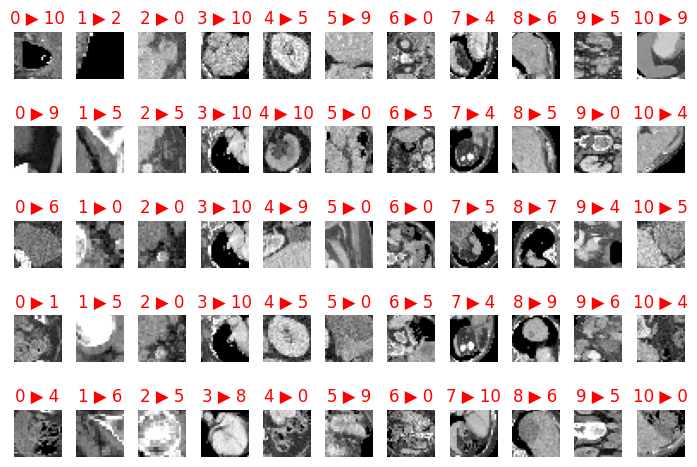

In [33]:
clean_misclassified_images, clean_misclassified_labels, clean_misclassified_preds = analyze_for_misclassifications(misclassified_images, misclassified_labels, misclassified_preds)


---
# ⚔️ Adversarial Attacks

In [34]:
attack_dataset = TensorDataset(correct_images, correct_labels)
attack_dataset_loader = DataLoader(attack_dataset, batch_size=128)

In [35]:
def perform_adv_attack(model, attack, data_loader):
    adv_data = []
    adv_labels = []
    device = next(model.parameters()).device

    total_batches = len(data_loader)
    progress_bar = tqdm.tqdm(total=total_batches, unit='batch', desc='Generating Adversarial Examples')

    for x, y in data_loader:
        x, y = x.to(device), y.to(device)

        # Convert labels to long data type
        y = y.long().squeeze()

        if adversarial_attack_name == "cw_attack":
            # Generate adversarial examples
            x_adv = attack.generate(x.cpu().numpy(), y.cpu().numpy())
            # Convert generated adversarial examples back to torch tensors and move to the original device
            x_adv = torch.tensor(x_adv).to(device)
            adv_data.append(x_adv.detach())
            adv_labels.append(y.detach())

        else:
            x_adv = attack(x, y)
            adv_data.append(x_adv.detach())
            adv_labels.append(y.detach())

        progress_bar.update(1)

    progress_bar.close()

    adv_data = torch.cat(adv_data)
    adv_labels = torch.cat(adv_labels)

    # Move data back to CPU if necessary
    if device != torch.device('cpu'):
        adv_data = adv_data.to('cpu')
        adv_labels = adv_labels.to('cpu')

    # Create dataset and loader
    adv_dataset = TensorDataset(adv_data, adv_labels)
    adv_loader = DataLoader(adv_dataset, batch_size=128)

    return adv_loader

In [36]:
def evaluate_adv_attack(model, data_loader, loss_fn, device):
    global ASR
    attack_test_loss = 0.0
    attack_test_accuracy = 0.0
    num_misclassified = 0

    # Lists to store predictions and true labels for metric calculations
    all_labels = []
    all_predictions = []

    # Set the model to evaluation mode
    model.eval()

    misclassified_images = []
    misclassified_labels = []
    misclassified_preds = []

    # Determine the total number of test images from data_loader
    dataset_size = len(data_loader.dataset)
    print(f"Number of adversarial test images: {dataset_size}")

    total_batches = 0
    with torch.no_grad():
        # Loop over all batches in the provided data_loader
        for x, y in data_loader:
            # Move data to the specified device
            x, y = x.to(device), y.to(device)

            # Forward pass
            logits = model(x)

            # Calculate loss for this batch
            batch_loss = loss_fn(logits, y)
            attack_test_loss += batch_loss.item()

            # Predictions and accuracy
            preds = torch.argmax(logits, dim=1)
            attack_test_accuracy += torch.sum(preds == y).item()

            # Append predictions and labels to the lists for later metric calculations
            all_predictions.extend(preds.cpu().numpy())
            all_labels.extend(y.cpu().numpy())

            # Identify misclassified samples in this batch
            incorrect_inds = torch.where(preds != y)[0]
            num_misclassified += len(incorrect_inds)
            if len(incorrect_inds) > 0:
                # Move misclassified samples to CPU
                misclassified_images.append(x[incorrect_inds].cpu())
                misclassified_labels.append(y[incorrect_inds].cpu())
                misclassified_preds.append(preds[incorrect_inds].cpu())

            total_batches += 1

    # Average the metrics over the entire dataset
    attack_test_loss /= total_batches
    attack_test_accuracy /= dataset_size

    ASR = num_misclassified/dataset_size

    print(f"Number of misclassified images: {num_misclassified} out of {dataset_size}")
    print(f"Test Loss (Adversarial Examples): {attack_test_loss:.4f} | Test Accuracy (Adversarial Examples): {attack_test_accuracy:.4f}")
    print(f"ASR: {ASR:.2%}\n")

    # Calculate and print additional metrics
    micro_precision = precision_score(all_labels, all_predictions, average='micro', zero_division=0)
    micro_recall = recall_score(all_labels, all_predictions, average='micro', zero_division=0)
    micro_f1 = f1_score(all_labels, all_predictions, average='micro', zero_division=0)

    macro_precision = precision_score(all_labels, all_predictions, average='macro', zero_division=0)
    macro_recall = recall_score(all_labels, all_predictions, average='macro', zero_division=0)
    macro_f1 = f1_score(all_labels, all_predictions, average='macro', zero_division=0)

    weighted_precision = precision_score(all_labels, all_predictions, average='weighted', zero_division=0)
    weighted_recall = recall_score(all_labels, all_predictions, average='weighted', zero_division=0)
    weighted_f1 = f1_score(all_labels, all_predictions, average='weighted', zero_division=0)

    table_data = [
        ["Micro-average", f"{micro_precision:.4f}", f"{micro_recall:.4f}", f"{micro_f1:.4f}"],
        ["Macro-average", f"{macro_precision:.4f}", f"{macro_recall:.4f}", f"{macro_f1:.4f}"],
        ["Weighted-average", f"{weighted_precision:.4f}", f"{weighted_recall:.4f}", f"{weighted_f1:.4f}"]
    ]

    headers = ["Metric", "Precision", "Recall", "F1-Score"]
    print(tabulate(table_data, headers=headers, tablefmt="grid"))

    # Handle cases where nothing is misclassified
    if len(misclassified_images) == 0:
        misclassified_images.append(torch.tensor([]))
    if len(misclassified_labels) == 0:
        misclassified_labels.append(torch.tensor([]))
    if len(misclassified_preds) == 0:
        misclassified_preds.append(torch.tensor([]))

    return (
        attack_test_loss,
        attack_test_accuracy,
        [torch.cat(misclassified_images)],
        [torch.cat(misclassified_labels)],
        [torch.cat(misclassified_preds)],
    )

---

In [37]:
# Select the adversarial attack from the following: fgsm_attack, pgd_attack, apgd_attack, vnifgsm_attack, vmifgsm_attack, sinifgsm_attack, cw_attack, deepfool_attack, onepixel_attack, square_attack
global adversarial_attack_name
adversarial_attack_name = 'fgsm_attack'

In [38]:
model = clean_model
# Define adversarial attacks
def adversarial_attack(choose_attack_option):
    if choose_attack_option == "fgsm_attack":
        attack = torchattacks.FGSM(model, eps=8/255)
    else:
        print("You did not chose any of the possible options or an you made an invalid option")
    return attack

In [39]:
attack = adversarial_attack(adversarial_attack_name)

In [40]:
# Start the timer
start_time = time.time()
# Generating Adversarial Examples
adv_attack_loader = perform_adv_attack(clean_model, attack, attack_dataset_loader)
# End the timer
end_time = time.time()

Generating Adversarial Examples: 100%|██████████| 50/50 [00:00<00:00, 188.40batch/s]


In [41]:
# Calculate generating adversarial examples duration in seconds
attack_duration_seconds = abs(end_time - start_time)
# Print the attack duration
print(f"Generating adversarial examples duration: {attack_duration_seconds:.2f} seconds")

Generating adversarial examples duration: 0.29 seconds


In [42]:
# Start the timer
start_time = time.time()
# Evaluate the adversarial attack
clean_attack_test_loss, clean_attack_adv_test_accuracy, misclassified_images, misclassified_labels, misclassified_preds = evaluate_adv_attack(clean_model, adv_attack_loader, loss_fn, device)
# End the timer
end_time = time.time()

Number of adversarial test images: 6301
Number of misclassified images: 3430 out of 6301
Test Loss (Adversarial Examples): 2.6673 | Test Accuracy (Adversarial Examples): 0.4556
ASR: 54.44%

+------------------+-------------+----------+------------+
| Metric           |   Precision |   Recall |   F1-Score |
+==================+=============+==========+============+
| Micro-average    |      0.4556 |   0.4556 |     0.4556 |
+------------------+-------------+----------+------------+
| Macro-average    |      0.4852 |   0.4062 |     0.4349 |
+------------------+-------------+----------+------------+
| Weighted-average |      0.5455 |   0.4556 |     0.4894 |
+------------------+-------------+----------+------------+


In [43]:
# Calculate the attack test duration in seconds
attack_test_duration_seconds = abs(end_time - start_time)
# Print the attack test duration
print(f"Adversarial examples test duration: {attack_test_duration_seconds:.2f} seconds")

Adversarial examples test duration: 0.24 seconds


Number of misclassified images: 3430


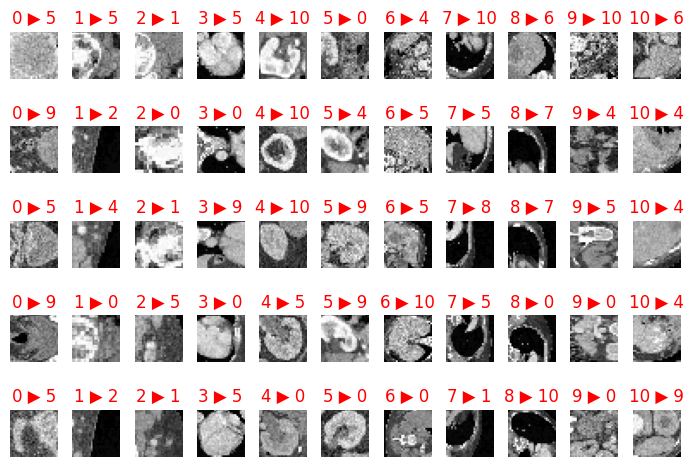

In [44]:
adv_misclassified_images, adv_misclassified_labels, adv_misclassified_preds = analyze_for_misclassifications(misclassified_images, misclassified_labels, misclassified_preds)

In [45]:
print("Dataset:", dataset_name)
target_model_name = target_model.__class__.__name__.lower() + "_model"
print("Target Model:", target_model_name)
if target_model_name == 'qnn_model':
   print("Entanglement Type:", entanglement_type)
print()
print(f"Original Detection Rate (ODR): {ODR:.2%}")
print(f"Attack Success Rate (ASR): {ASR:.2%}")
print()
# print(f"Total Time Cost (TTC): {ttc_seconds:.2f} seconds")
print(f"Adversarial Examples Generation Duration ({adversarial_attack_name}): {attack_duration_seconds:.2f} seconds")

Dataset: OrganAMNIST
Target Model: dnn_model

Original Detection Rate (ODR): 73.06%
Attack Success Rate (ASR): 54.44%

Adversarial Examples Generation Duration (fgsm_attack): 0.29 seconds


---

In [46]:
# Select the adversarial attack from the following: fgsm_attack, pgd_attack, apgd_attack, vnifgsm_attack, vmifgsm_attack, sinifgsm_attack, cw_attack, deepfool_attack, onepixel_attack, square_attack
global adversarial_attack_name
adversarial_attack_name = 'pgd_attack'

In [47]:
model = clean_model
# Define adversarial attacks
def adversarial_attack(choose_attack_option):
    if choose_attack_option == "pgd_attack":
        attack = torchattacks.PGD(model, eps=8/255, alpha=2/255, steps=10, random_start=True)
    else:
        print("You did not chose any of the possible options or an you made an invalid option")
    return attack

In [48]:
attack = adversarial_attack(adversarial_attack_name)

In [49]:
# Start the timer
start_time = time.time()
# Generating Adversarial Examples
adv_attack_loader = perform_adv_attack(clean_model, attack, attack_dataset_loader)
# End the timer
end_time = time.time()

Generating Adversarial Examples: 100%|██████████| 50/50 [00:01<00:00, 42.25batch/s]


In [50]:
# Calculate generating adversarial examples duration in seconds
attack_duration_seconds = abs(end_time - start_time)
# Print the attack duration
print(f"Generating adversarial examples duration: {attack_duration_seconds:.2f} seconds")

Generating adversarial examples duration: 1.20 seconds


In [51]:
# Start the timer
start_time = time.time()
# Evaluate the adversarial attack
clean_attack_test_loss, clean_attack_adv_test_accuracy, misclassified_images, misclassified_labels, misclassified_preds = evaluate_adv_attack(clean_model, adv_attack_loader, loss_fn, device)
# End the timer
end_time = time.time()

Number of adversarial test images: 6301
Number of misclassified images: 3682 out of 6301
Test Loss (Adversarial Examples): 3.1738 | Test Accuracy (Adversarial Examples): 0.4156
ASR: 58.44%

+------------------+-------------+----------+------------+
| Metric           |   Precision |   Recall |   F1-Score |
+==================+=============+==========+============+
| Micro-average    |      0.4156 |   0.4156 |     0.4156 |
+------------------+-------------+----------+------------+
| Macro-average    |      0.4549 |   0.3656 |     0.399  |
+------------------+-------------+----------+------------+
| Weighted-average |      0.5168 |   0.4156 |     0.4545 |
+------------------+-------------+----------+------------+


In [52]:
# Calculate the attack test duration in seconds
attack_test_duration_seconds = abs(end_time - start_time)
# Print the attack test duration
print(f"Adversarial examples test duration: {attack_test_duration_seconds:.2f} seconds")

Adversarial examples test duration: 0.25 seconds


Number of misclassified images: 3682


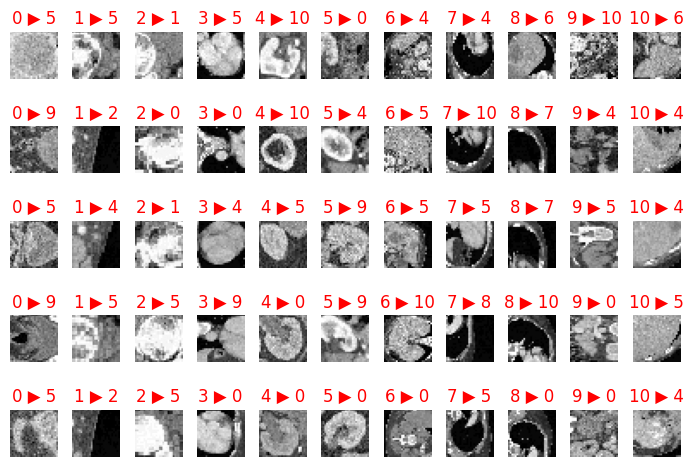

In [53]:
adv_misclassified_images, adv_misclassified_labels, adv_misclassified_preds = analyze_for_misclassifications(misclassified_images, misclassified_labels, misclassified_preds)

In [54]:
print("Dataset:", dataset_name)
target_model_name = target_model.__class__.__name__.lower() + "_model"
print("Target Model:", target_model_name)
if target_model_name == 'qnn_model':
   print("Entanglement Type:", entanglement_type)
print()
print(f"Original Detection Rate (ODR): {ODR:.2%}")
print(f"Attack Success Rate (ASR): {ASR:.2%}")
print()
# print(f"Total Time Cost (TTC): {ttc_seconds:.2f} seconds")
print(f"Adversarial Examples Generation Duration ({adversarial_attack_name}): {attack_duration_seconds:.2f} seconds")

Dataset: OrganAMNIST
Target Model: dnn_model

Original Detection Rate (ODR): 73.06%
Attack Success Rate (ASR): 58.44%

Adversarial Examples Generation Duration (pgd_attack): 1.20 seconds


---

In [55]:
# Select the adversarial attack from the following: fgsm_attack, pgd_attack, apgd_attack, vnifgsm_attack, vmifgsm_attack, sinifgsm_attack, cw_attack, deepfool_attack, onepixel_attack, square_attack
global adversarial_attack_name
adversarial_attack_name = 'apgd_attack'

In [56]:
model = clean_model
# Define adversarial attacks
def adversarial_attack(choose_attack_option):
    if choose_attack_option == "apgd_attack":
        attack = torchattacks.APGD(model, norm='Linf', eps=8/255, steps=10, n_restarts=1, seed=0, loss='ce', eot_iter=1, rho=0.75, verbose=False)
    else:
        print("You did not chose any of the possible options or an you made an invalid option")
    return attack

In [57]:
attack = adversarial_attack(adversarial_attack_name)

In [58]:
# Start the timer
start_time = time.time()
# Generating Adversarial Examples
adv_attack_loader = perform_adv_attack(clean_model, attack, attack_dataset_loader)
# End the timer
end_time = time.time()

Generating Adversarial Examples: 100%|██████████| 50/50 [00:03<00:00, 15.37batch/s]


In [59]:
# Calculate generating adversarial examples duration in seconds
attack_duration_seconds = abs(end_time - start_time)
# Print the attack duration
print(f"Generating adversarial examples duration: {attack_duration_seconds:.2f} seconds")

Generating adversarial examples duration: 3.26 seconds


In [60]:
# Start the timer
start_time = time.time()
# Evaluate the adversarial attack
clean_attack_test_loss, clean_attack_adv_test_accuracy, misclassified_images, misclassified_labels, misclassified_preds = evaluate_adv_attack(clean_model, adv_attack_loader, loss_fn, device)
# End the timer
end_time = time.time()

Number of adversarial test images: 6301
Number of misclassified images: 3734 out of 6301
Test Loss (Adversarial Examples): 3.2006 | Test Accuracy (Adversarial Examples): 0.4074
ASR: 59.26%

+------------------+-------------+----------+------------+
| Metric           |   Precision |   Recall |   F1-Score |
+==================+=============+==========+============+
| Micro-average    |      0.4074 |   0.4074 |     0.4074 |
+------------------+-------------+----------+------------+
| Macro-average    |      0.4491 |   0.3572 |     0.3916 |
+------------------+-------------+----------+------------+
| Weighted-average |      0.5111 |   0.4074 |     0.4471 |
+------------------+-------------+----------+------------+


In [61]:
# Calculate the attack test duration in seconds
attack_test_duration_seconds = abs(end_time - start_time)
# Print the attack test duration
print(f"Adversarial examples test duration: {attack_test_duration_seconds:.2f} seconds")

Adversarial examples test duration: 0.21 seconds


Number of misclassified images: 3734


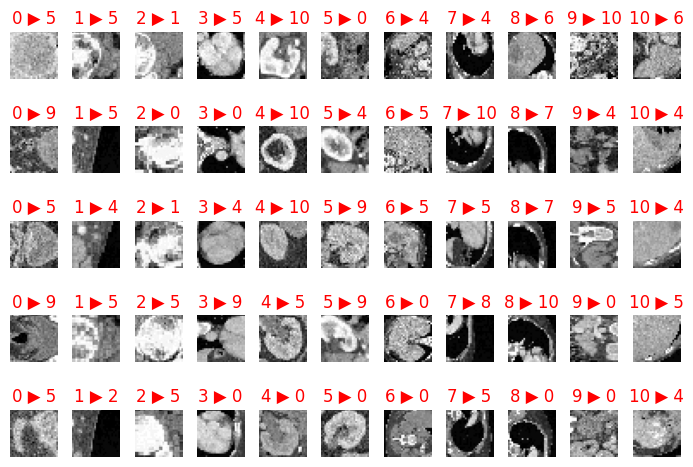

In [62]:
adv_misclassified_images, adv_misclassified_labels, adv_misclassified_preds = analyze_for_misclassifications(misclassified_images, misclassified_labels, misclassified_preds)

In [63]:
print("Dataset:", dataset_name)
target_model_name = target_model.__class__.__name__.lower() + "_model"
print("Target Model:", target_model_name)
if target_model_name == 'qnn_model':
   print("Entanglement Type:", entanglement_type)
print()
print(f"Original Detection Rate (ODR): {ODR:.2%}")
print(f"Attack Success Rate (ASR): {ASR:.2%}")
print()
# print(f"Total Time Cost (TTC): {ttc_seconds:.2f} seconds")
print(f"Adversarial Examples Generation Duration ({adversarial_attack_name}): {attack_duration_seconds:.2f} seconds")

Dataset: OrganAMNIST
Target Model: dnn_model

Original Detection Rate (ODR): 73.06%
Attack Success Rate (ASR): 59.26%

Adversarial Examples Generation Duration (apgd_attack): 3.26 seconds


---

In [64]:
# Select the adversarial attack from the following: fgsm_attack, pgd_attack, apgd_attack, vnifgsm_attack, vmifgsm_attack, sinifgsm_attack, cw_attack, deepfool_attack, onepixel_attack, square_attack
global adversarial_attack_name
adversarial_attack_name = 'vmifgsm_attack'

In [65]:
model = clean_model
# Define adversarial attacks
def adversarial_attack(choose_attack_option):
    if choose_attack_option == "vmifgsm_attack":
        attack = torchattacks.VMIFGSM(model, eps=8/255, alpha=2/255, steps=10, decay=1.0, N=5, beta=3/2)
    else:
        print("You did not chose any of the possible options or an you made an invalid option")
    return attack

In [66]:
attack = adversarial_attack(adversarial_attack_name)

In [67]:
# Start the timer
start_time = time.time()
# Generating Adversarial Examples
adv_attack_loader = perform_adv_attack(clean_model, attack, attack_dataset_loader)
# End the timer
end_time = time.time()

Generating Adversarial Examples: 100%|██████████| 50/50 [00:05<00:00,  8.57batch/s]


In [68]:
# Calculate generating adversarial examples duration in seconds
attack_duration_seconds = abs(end_time - start_time)
# Print the attack duration
print(f"Generating adversarial examples duration: {attack_duration_seconds:.2f} seconds")

Generating adversarial examples duration: 5.85 seconds


In [69]:
# Start the timer
start_time = time.time()
# Evaluate the adversarial attack
clean_attack_test_loss, clean_attack_adv_test_accuracy, misclassified_images, misclassified_labels, misclassified_preds = evaluate_adv_attack(clean_model, adv_attack_loader, loss_fn, device)
# End the timer
end_time = time.time()

Number of adversarial test images: 6301
Number of misclassified images: 3613 out of 6301
Test Loss (Adversarial Examples): 3.0686 | Test Accuracy (Adversarial Examples): 0.4266
ASR: 57.34%

+------------------+-------------+----------+------------+
| Metric           |   Precision |   Recall |   F1-Score |
+==================+=============+==========+============+
| Micro-average    |      0.4266 |   0.4266 |     0.4266 |
+------------------+-------------+----------+------------+
| Macro-average    |      0.4631 |   0.3766 |     0.4087 |
+------------------+-------------+----------+------------+
| Weighted-average |      0.5244 |   0.4266 |     0.4639 |
+------------------+-------------+----------+------------+


In [70]:
# Calculate the attack test duration in seconds
attack_test_duration_seconds = abs(end_time - start_time)
# Print the attack test duration
print(f"Adversarial examples test duration: {attack_test_duration_seconds:.2f} seconds")

Adversarial examples test duration: 0.21 seconds


Number of misclassified images: 3613


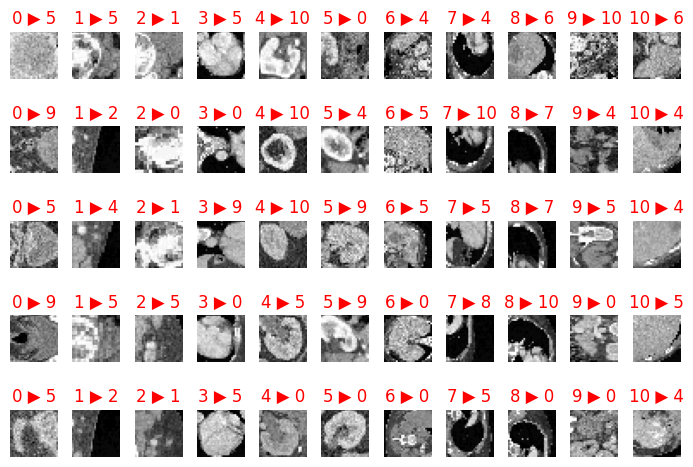

In [71]:
adv_misclassified_images, adv_misclassified_labels, adv_misclassified_preds = analyze_for_misclassifications(misclassified_images, misclassified_labels, misclassified_preds)

In [72]:
print("Dataset:", dataset_name)
target_model_name = target_model.__class__.__name__.lower() + "_model"
print("Target Model:", target_model_name)
if target_model_name == 'qnn_model':
   print("Entanglement Type:", entanglement_type)
print()
print(f"Original Detection Rate (ODR): {ODR:.2%}")
print(f"Attack Success Rate (ASR): {ASR:.2%}")
print()
# print(f"Total Time Cost (TTC): {ttc_seconds:.2f} seconds")
print(f"Adversarial Examples Generation Duration ({adversarial_attack_name}): {attack_duration_seconds:.2f} seconds")

Dataset: OrganAMNIST
Target Model: dnn_model

Original Detection Rate (ODR): 73.06%
Attack Success Rate (ASR): 57.34%

Adversarial Examples Generation Duration (vmifgsm_attack): 5.85 seconds


---

In [73]:
# Select the adversarial attack from the following: fgsm_attack, pgd_attack, apgd_attack, vnifgsm_attack, vmifgsm_attack, sinifgsm_attack, cw_attack, deepfool_attack, onepixel_attack, square_attack
global adversarial_attack_name
adversarial_attack_name = 'cw_attack'

In [74]:
model = clean_model
# Define adversarial attacks
def adversarial_attack(choose_attack_option):
    if choose_attack_option == "cw_attack":
        # attack = torchattacks.CW(model, c=1, kappa=0.0, steps=1000, lr=0.01)    # Torchattacks library (Not Functional)
        if dataset_name == "MNIST":
            input_shape = (1, 28, 28)
            num_classes = 10
        elif dataset_name == "CIFAR10":
            input_shape = (3, 32, 32)
            num_classes = 10
        elif dataset_name == "OrganAMNIST":
            input_shape = (1, 28, 28)
            num_classes = 11
        classifier = PyTorchClassifier(model=clean_model, loss=loss_fn, optimizer=optimizer, input_shape=input_shape, nb_classes=num_classes, clip_values=(0, 1)) # ART library
        attack = CarliniL2Method(classifier=classifier, confidence=0.0, targeted=False, learning_rate=0.05, binary_search_steps=8, max_iter=5, initial_const=0.01, max_halving=5, max_doubling=5, batch_size=128, verbose=False)
    else:
        print("You did not chose any of the possible options or an you made an invalid option")
    return attack

In [75]:
attack = adversarial_attack(adversarial_attack_name)

In [76]:
# Start the timer
start_time = time.time()
# Generating Adversarial Examples
adv_attack_loader = perform_adv_attack(clean_model, attack, attack_dataset_loader)
# End the timer
end_time = time.time()

Generating Adversarial Examples: 100%|██████████| 50/50 [03:05<00:00,  3.70s/batch]


In [77]:
# Calculate generating adversarial examples duration in seconds
attack_duration_seconds = abs(end_time - start_time)
# Print the attack duration
print(f"Generating adversarial examples duration: {attack_duration_seconds:.2f} seconds")

Generating adversarial examples duration: 185.08 seconds


In [78]:
# Start the timer
start_time = time.time()
# Evaluate the adversarial attack
clean_attack_test_loss, clean_attack_adv_test_accuracy, misclassified_images, misclassified_labels, misclassified_preds = evaluate_adv_attack(clean_model, adv_attack_loader, loss_fn, device)
# End the timer
end_time = time.time()

Number of adversarial test images: 6301
Number of misclassified images: 6203 out of 6301
Test Loss (Adversarial Examples): 0.9168 | Test Accuracy (Adversarial Examples): 0.0156
ASR: 98.44%

+------------------+-------------+----------+------------+
| Metric           |   Precision |   Recall |   F1-Score |
+==================+=============+==========+============+
| Micro-average    |      0.0156 |   0.0156 |     0.0156 |
+------------------+-------------+----------+------------+
| Macro-average    |      0.0359 |   0.0151 |     0.0179 |
+------------------+-------------+----------+------------+
| Weighted-average |      0.0375 |   0.0156 |     0.0188 |
+------------------+-------------+----------+------------+


In [79]:
# Calculate the attack test duration in seconds
attack_test_duration_seconds = abs(end_time - start_time)
# Print the attack test duration
print(f"Adversarial examples test duration: {attack_test_duration_seconds:.2f} seconds")

Adversarial examples test duration: 0.20 seconds


Number of misclassified images: 6203


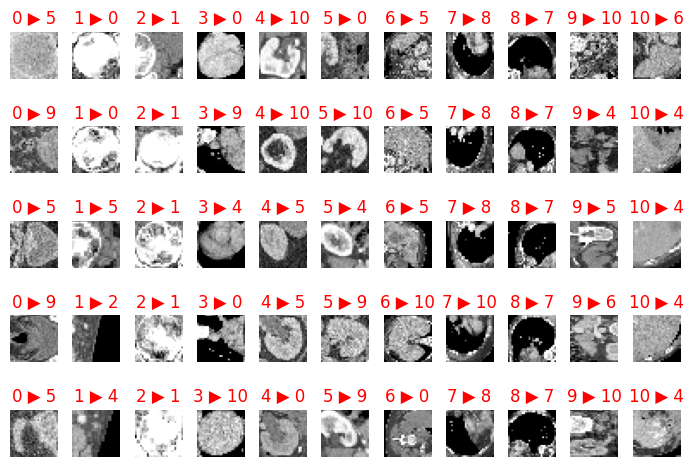

In [80]:
adv_misclassified_images, adv_misclassified_labels, adv_misclassified_preds = analyze_for_misclassifications(misclassified_images, misclassified_labels, misclassified_preds)

In [81]:
print("Dataset:", dataset_name)
target_model_name = target_model.__class__.__name__.lower() + "_model"
print("Target Model:", target_model_name)
if target_model_name == 'qnn_model':
   print("Entanglement Type:", entanglement_type)
print()
print(f"Original Detection Rate (ODR): {ODR:.2%}")
print(f"Attack Success Rate (ASR): {ASR:.2%}")
print()
# print(f"Total Time Cost (TTC): {ttc_seconds:.2f} seconds")
print(f"Adversarial Examples Generation Duration ({adversarial_attack_name}): {attack_duration_seconds:.2f} seconds")

Dataset: OrganAMNIST
Target Model: dnn_model

Original Detection Rate (ODR): 73.06%
Attack Success Rate (ASR): 98.44%

Adversarial Examples Generation Duration (cw_attack): 185.08 seconds


---

In [82]:
# Select the adversarial attack from the following: fgsm_attack, pgd_attack, apgd_attack, vnifgsm_attack, vmifgsm_attack, sinifgsm_attack, cw_attack, deepfool_attack, onepixel_attack, square_attack
global adversarial_attack_name
adversarial_attack_name = 'deepfool_attack'

In [83]:
model = clean_model
# Define adversarial attacks
def adversarial_attack(choose_attack_option):
    if choose_attack_option == "deepfool_attack":
        attack = torchattacks.DeepFool(model, steps=50, overshoot=0.05)
    else:
        print("You did not chose any of the possible options or an you made an invalid option")
    return attack

In [84]:
attack = adversarial_attack(adversarial_attack_name)

In [85]:
# Start the timer
start_time = time.time()
# Generating Adversarial Examples
adv_attack_loader = perform_adv_attack(clean_model, attack, attack_dataset_loader)
# End the timer
end_time = time.time()

Generating Adversarial Examples: 100%|██████████| 50/50 [15:45<00:00, 18.90s/batch]


In [86]:
# Calculate generating adversarial examples duration in seconds
attack_duration_seconds = abs(end_time - start_time)
# Print the attack duration
print(f"Generating adversarial examples duration: {attack_duration_seconds:.2f} seconds")

Generating adversarial examples duration: 945.15 seconds


In [87]:
# Start the timer
start_time = time.time()
# Evaluate the adversarial attack
clean_attack_test_loss, clean_attack_adv_test_accuracy, misclassified_images, misclassified_labels, misclassified_preds = evaluate_adv_attack(clean_model, adv_attack_loader, loss_fn, device)
# End the timer
end_time = time.time()

Number of adversarial test images: 6301
Number of misclassified images: 5512 out of 6301
Test Loss (Adversarial Examples): 1.6989 | Test Accuracy (Adversarial Examples): 0.1252
ASR: 87.48%

+------------------+-------------+----------+------------+
| Metric           |   Precision |   Recall |   F1-Score |
+==================+=============+==========+============+
| Micro-average    |      0.1252 |   0.1252 |     0.1252 |
+------------------+-------------+----------+------------+
| Macro-average    |      0.275  |   0.1122 |     0.1469 |
+------------------+-------------+----------+------------+
| Weighted-average |      0.3138 |   0.1252 |     0.1675 |
+------------------+-------------+----------+------------+


In [88]:
# Calculate the attack test duration in seconds
attack_test_duration_seconds = abs(end_time - start_time)
# Print the attack test duration
print(f"Adversarial examples test duration: {attack_test_duration_seconds:.2f} seconds")

Adversarial examples test duration: 0.20 seconds


Number of misclassified images: 5512


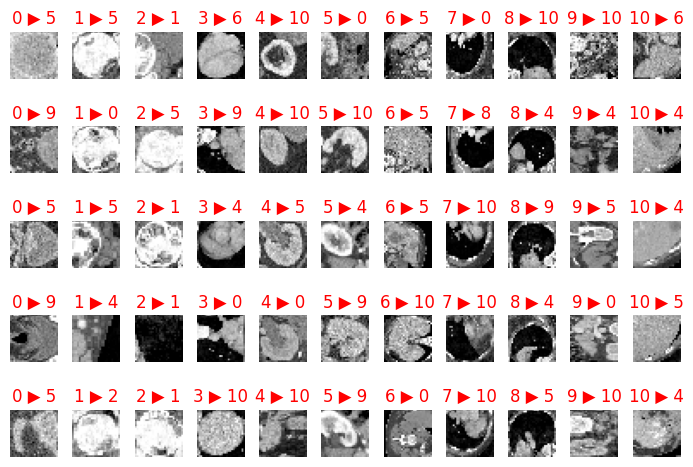

In [89]:
adv_misclassified_images, adv_misclassified_labels, adv_misclassified_preds = analyze_for_misclassifications(misclassified_images, misclassified_labels, misclassified_preds)

In [90]:
print("Dataset:", dataset_name)
target_model_name = target_model.__class__.__name__.lower() + "_model"
print("Target Model:", target_model_name)
if target_model_name == 'qnn_model':
   print("Entanglement Type:", entanglement_type)
print()
print(f"Original Detection Rate (ODR): {ODR:.2%}")
print(f"Attack Success Rate (ASR): {ASR:.2%}")
print()
# print(f"Total Time Cost (TTC): {ttc_seconds:.2f} seconds")
print(f"Adversarial Examples Generation Duration ({adversarial_attack_name}): {attack_duration_seconds:.2f} seconds")

Dataset: OrganAMNIST
Target Model: dnn_model

Original Detection Rate (ODR): 73.06%
Attack Success Rate (ASR): 87.48%

Adversarial Examples Generation Duration (deepfool_attack): 945.15 seconds


---

In [91]:
# Select the adversarial attack from the following: fgsm_attack, pgd_attack, apgd_attack, vnifgsm_attack, vmifgsm_attack, sinifgsm_attack, cw_attack, deepfool_attack, onepixel_attack, square_attack
global adversarial_attack_name
adversarial_attack_name = 'onepixel_attack'

In [92]:
model = clean_model
# Define adversarial attacks
def adversarial_attack(choose_attack_option):
    if choose_attack_option == "onepixel_attack":
        attack = torchattacks.OnePixel(model, pixels=1, steps=10, popsize=10, inf_batch=128)
    else:
        print("You did not chose any of the possible options or an you made an invalid option")
    return attack

In [93]:
attack = adversarial_attack(adversarial_attack_name)

In [94]:
# Start the timer
start_time = time.time()
# Generating Adversarial Examples
adv_attack_loader = perform_adv_attack(clean_model, attack, attack_dataset_loader)
# End the timer
end_time = time.time()

Generating Adversarial Examples: 100%|██████████| 50/50 [02:59<00:00,  3.58s/batch]


In [95]:
# Calculate generating adversarial examples duration in seconds
attack_duration_seconds = abs(end_time - start_time)
# Print the attack duration
print(f"Generating adversarial examples duration: {attack_duration_seconds:.2f} seconds")

Generating adversarial examples duration: 179.05 seconds


In [96]:
# Start the timer
start_time = time.time()
# Evaluate the adversarial attack
clean_attack_test_loss, clean_attack_adv_test_accuracy, misclassified_images, misclassified_labels, misclassified_preds = evaluate_adv_attack(clean_model, adv_attack_loader, loss_fn, device)
# End the timer
end_time = time.time()

Number of adversarial test images: 6301
Number of misclassified images: 310 out of 6301
Test Loss (Adversarial Examples): 0.1250 | Test Accuracy (Adversarial Examples): 0.9508
ASR: 4.92%

+------------------+-------------+----------+------------+
| Metric           |   Precision |   Recall |   F1-Score |
+==================+=============+==========+============+
| Micro-average    |      0.9508 |   0.9508 |     0.9508 |
+------------------+-------------+----------+------------+
| Macro-average    |      0.9472 |   0.9429 |     0.9444 |
+------------------+-------------+----------+------------+
| Weighted-average |      0.9531 |   0.9508 |     0.9513 |
+------------------+-------------+----------+------------+


In [97]:
# Calculate the attack test duration in seconds
attack_test_duration_seconds = abs(end_time - start_time)
# Print the attack test duration
print(f"Adversarial examples test duration: {attack_test_duration_seconds:.2f} seconds")

Adversarial examples test duration: 0.21 seconds


Number of misclassified images: 310


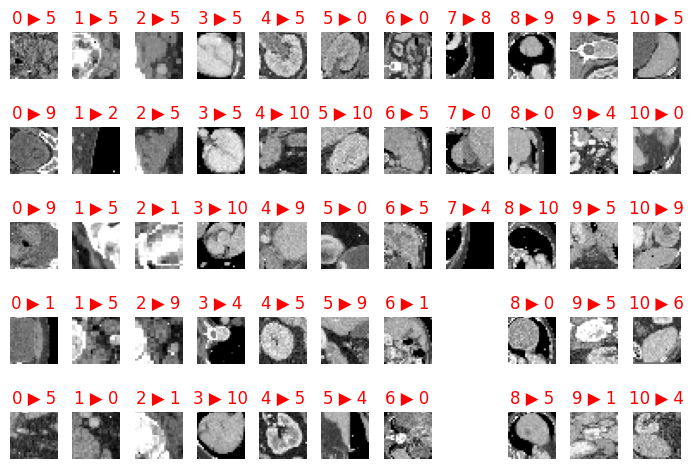

In [98]:
adv_misclassified_images, adv_misclassified_labels, adv_misclassified_preds = analyze_for_misclassifications(misclassified_images, misclassified_labels, misclassified_preds)

In [99]:
print("Dataset:", dataset_name)
target_model_name = target_model.__class__.__name__.lower() + "_model"
print("Target Model:", target_model_name)
if target_model_name == 'qnn_model':
   print("Entanglement Type:", entanglement_type)
print()
print(f"Original Detection Rate (ODR): {ODR:.2%}")
print(f"Attack Success Rate (ASR): {ASR:.2%}")
print()
# print(f"Total Time Cost (TTC): {ttc_seconds:.2f} seconds")
print(f"Adversarial Examples Generation Duration ({adversarial_attack_name}): {attack_duration_seconds:.2f} seconds")

Dataset: OrganAMNIST
Target Model: dnn_model

Original Detection Rate (ODR): 73.06%
Attack Success Rate (ASR): 4.92%

Adversarial Examples Generation Duration (onepixel_attack): 179.05 seconds


---

In [100]:
# Select the adversarial attack from the following: fgsm_attack, pgd_attack, apgd_attack, vnifgsm_attack, vmifgsm_attack, sinifgsm_attack, cw_attack, deepfool_attack, onepixel_attack, square_attack
global adversarial_attack_name
adversarial_attack_name = 'square_attack'

In [101]:
model = clean_model
# Define adversarial attacks
def adversarial_attack(choose_attack_option):
    if choose_attack_option == "square_attack":
        attack = torchattacks.Square(model, norm='Linf', eps=8/255, n_queries=500, n_restarts=1, p_init=0.8, loss='margin', resc_schedule=True, seed=0, verbose=False)
    else:
        print("You did not chose any of the possible options or an you made an invalid option")
    return attack

In [102]:
attack = adversarial_attack(adversarial_attack_name)

In [103]:
# Start the timer
start_time = time.time()
# Generating Adversarial Examples
adv_attack_loader = perform_adv_attack(clean_model, attack, attack_dataset_loader)
# End the timer
end_time = time.time()

Generating Adversarial Examples: 100%|██████████| 50/50 [01:03<00:00,  1.26s/batch]


In [104]:
# Calculate generating adversarial examples duration in seconds
attack_duration_seconds = abs(end_time - start_time)
# Print the attack duration
print(f"Generating adversarial examples duration: {attack_duration_seconds:.2f} seconds")

Generating adversarial examples duration: 63.06 seconds


In [105]:
# Start the timer
start_time = time.time()
# Evaluate the adversarial attack
clean_attack_test_loss, clean_attack_adv_test_accuracy, misclassified_images, misclassified_labels, misclassified_preds = evaluate_adv_attack(clean_model, adv_attack_loader, loss_fn, device)
# End the timer
end_time = time.time()

Number of adversarial test images: 6301
Number of misclassified images: 2273 out of 6301
Test Loss (Adversarial Examples): 0.3186 | Test Accuracy (Adversarial Examples): 0.6393
ASR: 36.07%

+------------------+-------------+----------+------------+
| Metric           |   Precision |   Recall |   F1-Score |
+==================+=============+==========+============+
| Micro-average    |      0.6393 |   0.6393 |     0.6393 |
+------------------+-------------+----------+------------+
| Macro-average    |      0.6428 |   0.5971 |     0.6097 |
+------------------+-------------+----------+------------+
| Weighted-average |      0.6906 |   0.6393 |     0.655  |
+------------------+-------------+----------+------------+


In [106]:
# Calculate the attack test duration in seconds
attack_test_duration_seconds = abs(end_time - start_time)
# Print the attack test duration
print(f"Adversarial examples test duration: {attack_test_duration_seconds:.2f} seconds")

Adversarial examples test duration: 0.24 seconds


Number of misclassified images: 2273


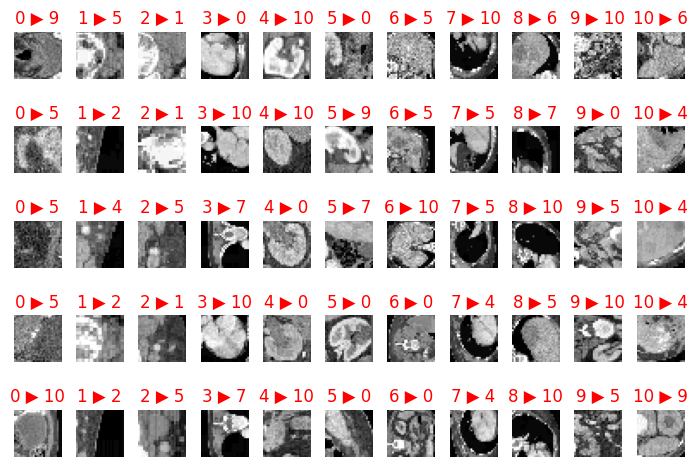

In [107]:
adv_misclassified_images, adv_misclassified_labels, adv_misclassified_preds = analyze_for_misclassifications(misclassified_images, misclassified_labels, misclassified_preds)

In [108]:
print("Dataset:", dataset_name)
target_model_name = target_model.__class__.__name__.lower() + "_model"
print("Target Model:", target_model_name)
if target_model_name == 'qnn_model':
   print("Entanglement Type:", entanglement_type)
print()
print(f"Original Detection Rate (ODR): {ODR:.2%}")
print(f"Attack Success Rate (ASR): {ASR:.2%}")
print()
# print(f"Total Time Cost (TTC): {ttc_seconds:.2f} seconds")
print(f"Adversarial Examples Generation Duration ({adversarial_attack_name}): {attack_duration_seconds:.2f} seconds")

Dataset: OrganAMNIST
Target Model: dnn_model

Original Detection Rate (ODR): 73.06%
Attack Success Rate (ASR): 36.07%

Adversarial Examples Generation Duration (square_attack): 63.06 seconds


---